# Various Data Tests

In [1]:
import pandas as pd
import numpy as np
import random
import os
import torch
import faiss
import json
import re
import shutil
import random
from tqdm import tqdm
from collections import Counter
from torch import Tensor
from dotenv import load_dotenv
from huggingface_hub import login
from torch.utils.data import DataLoader
import torch.nn.functional as F
from scipy.spatial.distance import jensenshannon
from beir.datasets.data_loader import GenericDataLoader
from sklearn.metrics.pairwise import cosine_similarity
from transformers import AutoTokenizer, logging, AutoModel, AutoModelForCausalLM
logging.set_verbosity_error()
import matplotlib.pyplot as plt
import spacy
nlp = spacy.load("en_core_web_sm")

/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco"
corpus, queries, qrels = GenericDataLoader(data_folder=data_dir).load(split='train')
test_corpus, test_queries, test_qrels = GenericDataLoader(data_folder=data_dir).load(split='dev')

100%|██████████| 8841823/8841823 [01:15<00:00, 116887.18it/s]


In [105]:
print(len(test_queries))

6980


In [27]:
pass_info = [(key, list(qrels[key].keys())[0], list(qrels[key].values())[0]) 
             for key in qrels.keys() if len(qrels[key]) < 2]
print(len(pass_info))

477587


In [33]:
print(f"Expected days to create new synthetic agentic passages: {(len(pass_info)/128*0.8)/60/24} days")

Expected days to create new synthetic agentic passages: 2.0728602430555556 days


In [3]:
test_q = [(q_id, query) for q_id, query in test_queries.items()]
train_q = [(q_id, query) for q_id, query in queries.items()]

# Query cosine similarity

In [104]:
df = pd.read_json("/work/mbouthil/datasets/test_results/sim_info_test.jsonl", lines=True)
df.head(20)

,train_id,test_id,sim_score,train_query,test_query
0,441269,125705,0.770052,literal define,define preventive
1,130335,125705,0.779247,definition chemical,define preventive
2,1185868,9083,0.757559,_________ justice is designed to repair the ha...,____________________ is considered the father ...
3,310130,320792,0.809511,how much does a lipid panel cost,how much is a cost to run disneyland
4,308543,320792,0.800558,how much does a ballet dancer make,how much is a cost to run disneyland
5,1164799,54544,0.772034,what causes ear infection in adults,blood diseases that are sexually transmitted
6,186617,87892,0.800466,fibroid symptoms after menopause,causes of petechial hemorrhage
7,186617,1090242,0.764471,fibroid symptoms after menopause,symptoms of ptsd in vietnam veterans
8,503515,92542,0.758506,steering define,circulation money definition
9,130335,92542,0.751946,definition chemical,circulation money definition


# Analyzing Word Distributions

## Training and testing query distributions

In [5]:
def tokenize_corpus(corpus, stop_words=None):
    tokens = []
    for doc in corpus:
        for word in doc.split():
            if stop_words and word.lower() in stop_words:
                continue
            tokens.append(word.lower())
    return tokens

def relative_freq(tokens):
    counts = Counter(tokens)
    total = sum(counts.values())
    return {w:c/total for w,c in counts.items()}

In [6]:
all_queries = list(queries.values()) + list(test_queries.values())

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [7]:
train_tokens = tokenize_corpus(list(queries.values()), stop_words=stop_words)
test_tokens = tokenize_corpus(list(test_queries.values()), stop_words=stop_words)

train_dist = relative_freq(train_tokens)
test_dist = relative_freq(test_tokens)

vocab = sorted(set(train_dist.keys()).union(test_dist.keys()))

In [8]:
from scipy.spatial.distance import jensenshannon

train_vec = np.array([train_dist.get(w,0) for w in vocab])
test_vec = np.array([test_dist.get(w,0) for w in vocab])

js = jensenshannon(train_vec, test_vec)

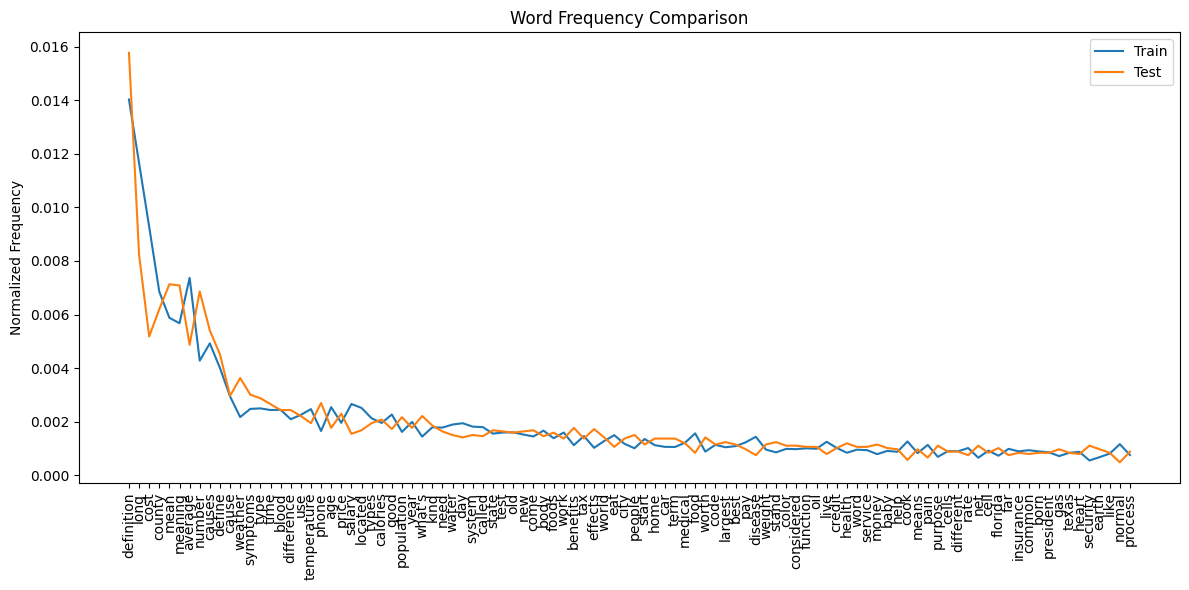

JS divergence: 0.4230072873562388


In [9]:
order = np.argsort(train_vec + test_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 100
vocab_sorted = [vocab[i] for i in order[:K]]
train_sorted = train_vec[order][:K]
test_sorted  = test_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, train_sorted, label="Train")
plt.plot(x, test_sorted, label="Test")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

## Synthetic Queries

In [11]:
# Loading in synthetically enhanced dataset
data_dir = "/work/mbouthil/datasets/msmarco_syn_q"
synq_corpus, synq_queries, synq_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:16<00:00, 116339.24it/s]


In [12]:
key = [key for key in queries.keys()][0]
max_id = max([int(key) for key in queries.keys()])

print(f"Oringinal query:\n{queries[key]}")
print("")
print(f"Synthetic query:\n{synq_queries[str(max_id+1)]}")

Oringinal query:
)what was the immediate impact of the success of the manhattan project?

Synthetic query:
What were the direct consequences of the Manhattan Project's achievement?


In [13]:
key = [key for key in queries.keys()][1]
print(f"Oringinal query:\n{queries[key]}")
print("")
print(f"Synthetic query:\n{synq_queries[str(max_id+2)]}")

Oringinal query:
_________ justice is designed to repair the harm to victim, the community and the offender caused by the offender criminal act. question 19 options:

Synthetic query:
What is the primary goal of restorative justice in addressing the consequences of a criminal offense?


In [14]:
N = len(queries)

all_queries = list(synq_queries.values()) + list(queries.values())

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [15]:
synq_tokens = tokenize_corpus(list(synq_queries.values())[N:], stop_words=stop_words)
orig_tokens = tokenize_corpus(list(test_queries.values())[:N], stop_words=stop_words)

synq_dist = relative_freq(synq_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(synq_dist.keys()).union(orig_dist.keys()))

synq_vec = np.array([synq_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(synq_vec, orig_vec)

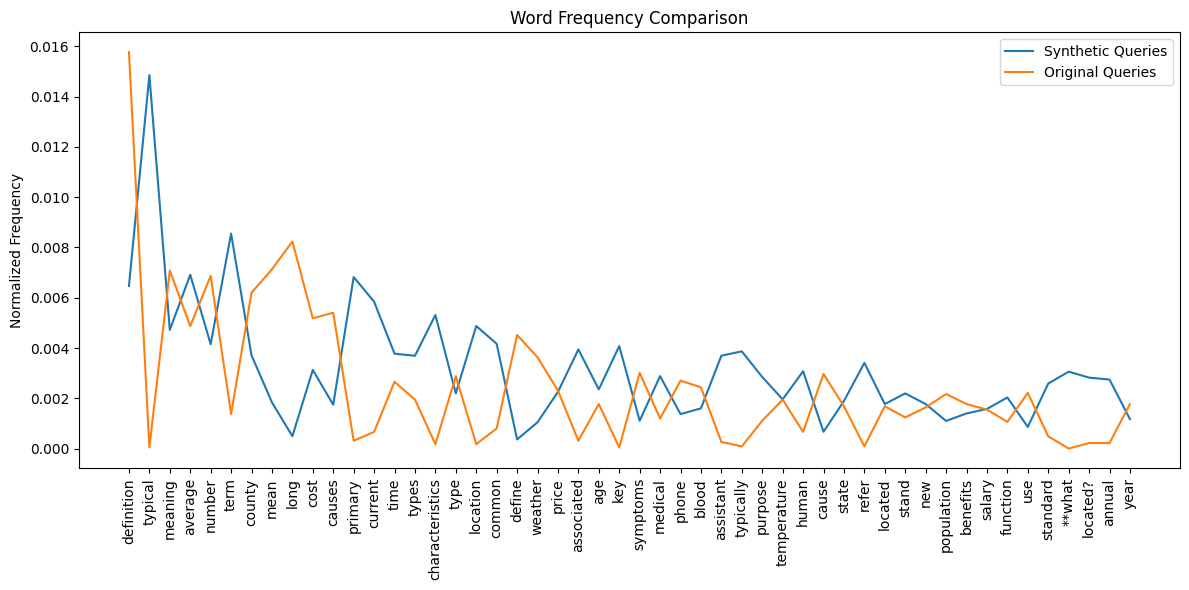

JS divergence: 0.5577054811505201


In [16]:
order = np.argsort(synq_vec + orig_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = synq_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Queries")
plt.plot(x, orig_sorted, label="Original Queries")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

## Agentic Synthetic Queries

In [18]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_syn_q_agent"
sqa_corpus, sqa_queries, sqa_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:17<00:00, 113977.12it/s]


In [19]:
N = len(queries)
print(f"Synthetically enhaced query data: {len(sqa_queries)}")
print(f"Original query data: {N}")
print(f"Synthetic query: {len(sqa_queries)-N}")

Synthetically enhaced query data: 971372
Original query data: 502939
Synthetic query: 468433


In [20]:
max_id = max([int(key) for key in queries.keys()])
print("Sample Syntehtic Agnetic Queries:")
for i in range(max_id+1, max_id+3):
    print(sqa_queries[str(i)])

Sample Syntehtic Agnetic Queries:
What were the direct outcomes of the Manhattan Project's achievement?
What is the primary goal of restorative justice in relation to addressing the consequences of a criminal offense on the victim, the community, and the offender?


In [21]:
q_text = list(queries.values())
all_queries = list(sqa_queries.values()) + q_text

words = set([word
        for query in all_queries
        for word in query.split()])

stop_words = set([stop_word for stop_word in words if stop_word in nlp.Defaults.stop_words])

In [22]:
synq_tokens = tokenize_corpus(list(sqa_queries.values())[N:], stop_words=stop_words)
orig_tokens = tokenize_corpus(q_text, stop_words=stop_words)

synq_dist = relative_freq(synq_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(synq_dist.keys()).union(orig_dist.keys()))

synq_vec = np.array([synq_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(synq_vec, orig_vec)

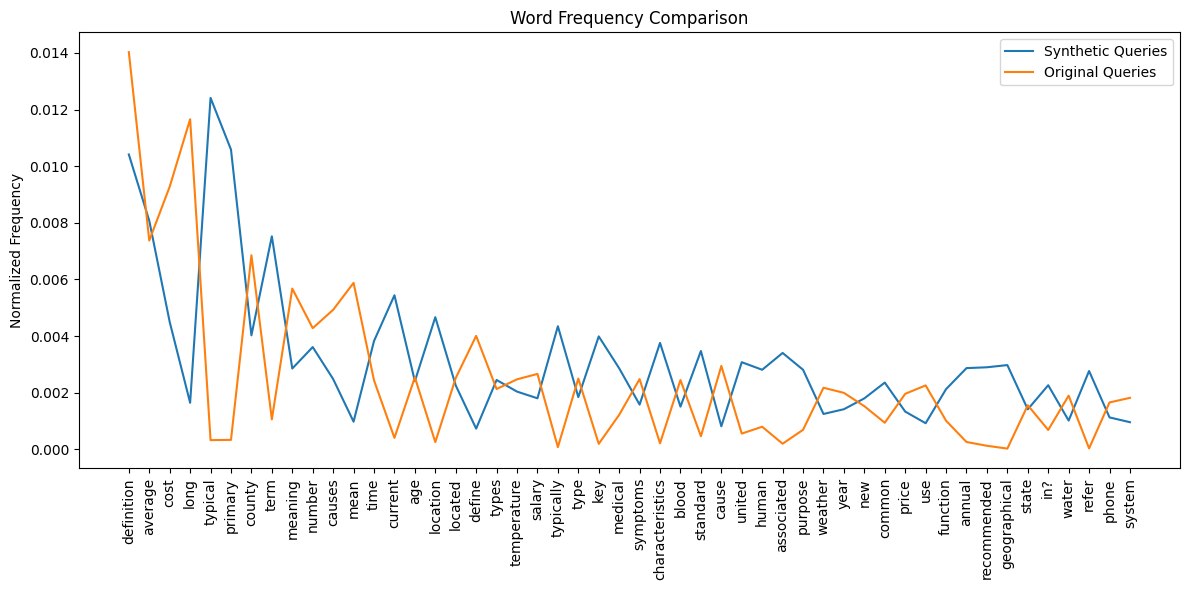

JS divergence: 0.4268401715753628


In [23]:
order = np.argsort(synq_vec + orig_vec)[::-1]
# order = np.argsort(train_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = synq_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Queries")
plt.plot(x, orig_sorted, label="Original Queries")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

## Synthetic Passages 

In [77]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_syn_p"
synp_corpus, synp_queries, synp_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 9319410/9319410 [01:17<00:00, 120947.74it/s]


In [78]:
print(f"Synthetically enhaced passage data: {len(synp_corpus)}")
print(f"Original passage data: {len(corpus)}")
print(f"Synthetic passages: {len(synp_corpus)-len(corpus)}")

Synthetically enhaced passage data: 9319410
Original passage data: 8841823
Synthetic passages: 477587


In [79]:
# Gathering original single passages
single_pass_info = [(key, list(qrels[key].keys())[0], list(qrels[key].values())[0]) 
             for key in qrels.keys() if len(qrels[key]) < 2]

single_passages = [corpus[id] for _, id, _ in single_pass_info]

In [80]:
print(f"Oringial passage:\n{single_passages[0]['text']}")
print("")
print(f"Synthetic passage:\n{synp_corpus[str(len(corpus))]['text']}")

Oringial passage:
The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.

Synthetic passage:
The collaboration and exchange of ideas among scientists played a crucial role in the success of the Manhattan Project, rivaling the significance of their exceptional scientific expertise. The only shadow cast over the remarkable accomplishments of the atomic researchers and engineers is the devastating reality of the consequences of their achievement: the loss of hundreds of thousands of innocent lives.


In [81]:
print(f"Oringial passage:\n{single_passages[1]['text']}")
print("")
print(f"Synthetic passage:\n{synp_corpus[str(len(corpus)+1)]['text']}")

Oringial passage:
The approach is based on a theory of justice that considers crime and wrongdoing to be an offense against an individual or community, rather than the State. Restorative justice that fosters dialogue between victim and offender has shown the highest rates of victim satisfaction and offender accountability.

Synthetic passage:
Restorative justice is grounded in a theory of justice that views crime and wrongdoing as a personal offense against an individual or community, rather than solely against the State. This approach has demonstrated the highest levels of victim satisfaction and offender accountability through fostering dialogue between the victim and the offender.


### Comparing Original Passage Dist. to Synthetic passage Dist

In [82]:
keys = list(range(len(corpus), len(synp_corpus)))
synp_passages = [synp_corpus[str(key)]['text'] for key in keys]
orig_passages = [passage['text'] for passage in single_passages]

In [83]:
all_passages = orig_passages + synp_passages
all_words = set([word 
                 for passage in all_passages
                 for word in passage.split()])

stop_words = set([stop_word 
                  for stop_word in all_words 
                  if stop_word in nlp.Defaults.stop_words])

In [84]:
synp_tokens = tokenize_corpus(synp_passages, stop_words=stop_words)
orig_tokens = tokenize_corpus(orig_passages, stop_words=stop_words)

synp_dist = relative_freq(synp_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(synp_dist.keys()).union(orig_dist.keys()))

synp_vec = np.array([synp_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(synp_vec, orig_vec)
print("JS divergence:", js)

JS divergence: 0.2560950303959256


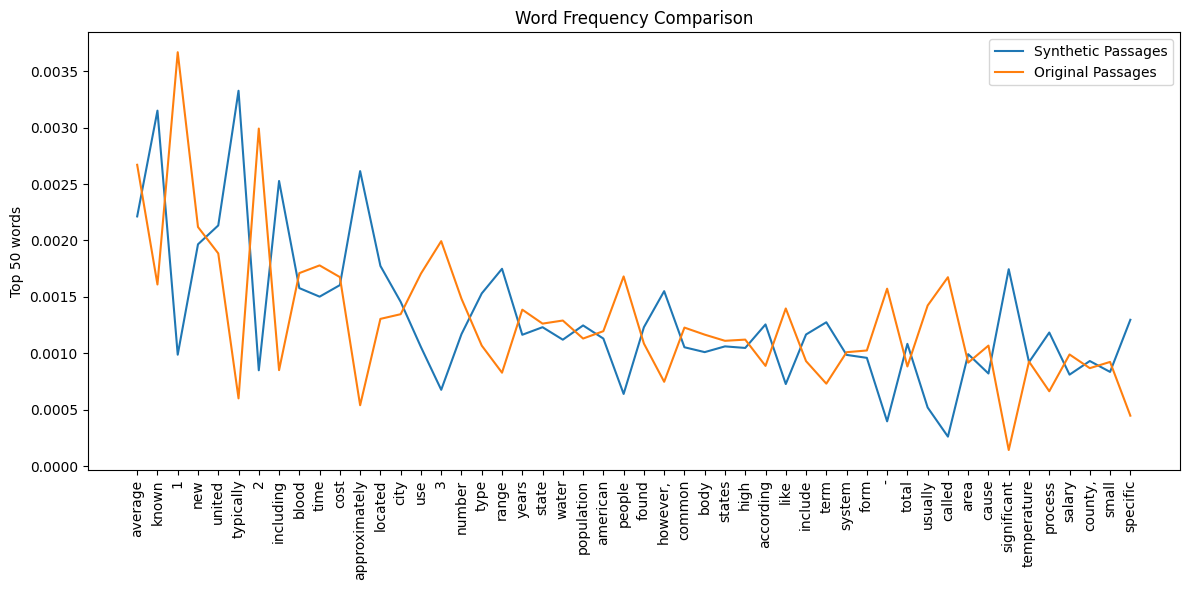

JS divergence: 0.2560950303959256


In [85]:
order = np.argsort(synp_vec + orig_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = synp_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Passages")
plt.plot(x, orig_sorted, label="Original Passages")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.ylabel(f"Top {K} words")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

In [86]:
print("Some synthetic passage examples:")
print("\n")
for i in range(len(corpus), len(corpus)+5):
    print(synp_corpus[str(i)]['text'])
    print("")

Some synthetic passage examples:


The collaboration and exchange of ideas among scientists played a crucial role in the success of the Manhattan Project, rivaling the significance of their exceptional scientific expertise. The only shadow cast over the remarkable accomplishments of the atomic researchers and engineers is the devastating reality of the consequences of their achievement: the loss of hundreds of thousands of innocent lives.

Restorative justice is grounded in a theory of justice that views crime and wrongdoing as a personal offense against an individual or community, rather than solely against the State. This approach has demonstrated the highest levels of victim satisfaction and offender accountability through fostering dialogue between the victim and the offender.

Color of Urine Can Vary Significantly

Inborn errors of bile acid synthesis can cause severe cholestatic liver disease, which typically manifests in infancy, and progressive neurological disorders that may a

## Agnetic Synthetic Passages

In [87]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_syn_p_agent_t4"
synp_corpus, synp_queries, synp_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841924/8841924 [01:19<00:00, 111106.66it/s]


In [88]:
diff = len(synp_corpus) - len(corpus)
print(f"Number of new (synthetic) passages: {diff}")

Number of new (synthetic) passages: 100


In [89]:
pass_info = [(key, list(qrels[key].keys())[0], list(qrels[key].values())[0]) 
             for key in qrels.keys() if len(qrels[key]) < 2]

In [90]:
max_id = max([int(key) for key in corpus.keys()])
orig_passages = [corpus[id]['text'] for _, id, _ in pass_info][:128]
synq_passages = [synp_corpus[str(id)]['text'] for id in list(range(max_id, max_id+diff))]

In [91]:
all_passages = orig_passages + synq_passages
all_words = set([word 
                 for passage in all_passages
                 for word in passage.split()])

stop_words = set([stop_word 
                  for stop_word in all_words 
                  if stop_word in nlp.Defaults.stop_words])

In [92]:
synp_tokens = tokenize_corpus(synq_passages, stop_words=stop_words)
orig_tokens = tokenize_corpus(orig_passages, stop_words=stop_words)

synp_dist = relative_freq(synp_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(synp_dist.keys()).union(orig_dist.keys()))

synp_vec = np.array([synp_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(synp_vec, orig_vec)

/tmp/ipykernel_3085097/3805521571.py:19: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3085097/3805521571.py:19: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


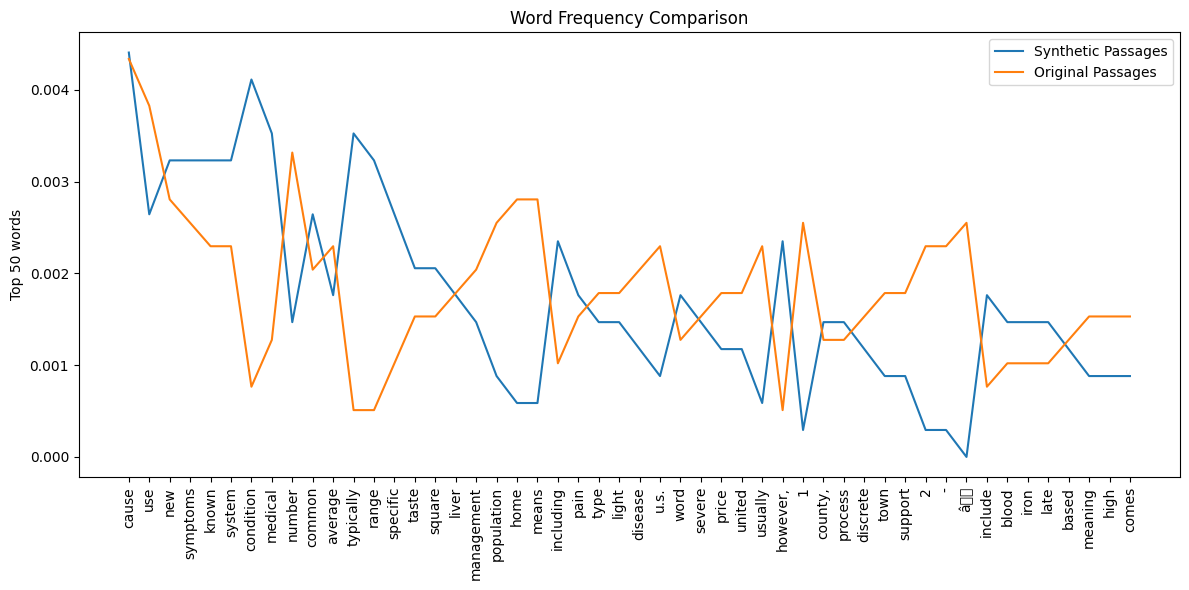

JS divergence: 0.5538029571501959


In [93]:
order = np.argsort(synp_vec + orig_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = synp_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Passages")
plt.plot(x, orig_sorted, label="Original Passages")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.ylabel(f"Top {K} words")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

## Synthetic Passages v2

In [94]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco_syn_p_v2"
synp_corpus, synp_queries, synp_qrels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841951/8841951 [01:14<00:00, 118050.08it/s]


In [95]:
print(f"Synthetically enhaced passage data length: {len(synp_corpus)}")
print(f"Number of original passage data: {len(corpus)}")
print(f"Number of new synthetic passages: {len(synp_corpus)-len(corpus)}")

Synthetically enhaced passage data length: 8841951
Number of original passage data: 8841823
Number of new synthetic passages: 128


In [96]:
# Gathering original single passages
single_pass_info = [(key, list(qrels[key].keys())[0], list(qrels[key].values())[0]) 
             for key in qrels.keys() if len(qrels[key]) < 2]

single_passages = [corpus[id] for _, id, _ in single_pass_info]

In [97]:
print(f"Oringial passage:\n{single_passages[0]['text']}")
print("")
print(f"Synthetic passage:\n{synp_corpus[str(len(corpus)+1)]['text']}")

Oringial passage:
The presence of communication amid scientific minds was equally important to the success of the Manhattan Project as scientific intellect was. The only cloud hanging over the impressive achievement of the atomic researchers and engineers is what their success truly meant; hundreds of thousands of innocent lives obliterated.

Synthetic passage:
The immediate impact of the success of the Manhattan Project, which was a research and development project that produced the atomic bomb during World War II, was multifaceted and far-reaching. The project's success led to the development of the first nuclear weapons, which were used in combat for the first time in history.

The immediate impact of the atomic bombings of Hiroshima and Nagasaki on August 6 and 9, 1945, respectively, was devastating. The bombings resulted in the deaths of an estimated 140,000 people in Hiroshima and 80,000 in Nagasaki, with many more suffering from injuries and long-term health effects. The bombing

In [61]:
## it is hallucinating...?

In [98]:
print(f"Oringial passage:\n{single_passages[1]['text']}")
print("")
print(f"Synthetic passage:\n{synp_corpus[str(len(corpus)+2)]['text']}")

Oringial passage:
The approach is based on a theory of justice that considers crime and wrongdoing to be an offense against an individual or community, rather than the State. Restorative justice that fosters dialogue between victim and offender has shown the highest rates of victim satisfaction and offender accountability.

Synthetic passage:
Restorative justice is a concept designed to repair the harm caused by an offender's criminal act to the victim, the community, and the offender themselves. This approach focuses on addressing the consequences of the offense and promoting healing, accountability, and reparation. Restorative justice seeks to repair the harm caused by the offense by bringing together the victim, the offender, and members of the community to discuss the impact of the offense and work towards a resolution.

Restorative justice is often contrasted with the traditional punitive approach to justice, which focuses on punishment and retribution. In contrast, restorative ju

In [99]:
diff = len(synp_corpus) - len(corpus)
max_id = max([int(key) for key in corpus.keys()])
orig_passages = [corpus[id]['text'] for _, id, _ in pass_info][:128]

In [100]:
print(max_id+1)

8841823


In [101]:
synq_passages = [synp_corpus[str(id)]['text'] for id in list(range(max_id+2, max_id+diff))]

In [102]:
all_passages = orig_passages + synq_passages
all_words = set([word 
                 for passage in all_passages
                 for word in passage.split()])

stop_words = set([stop_word 
                  for stop_word in all_words 
                  if stop_word in nlp.Defaults.stop_words])

synp_tokens = tokenize_corpus(synq_passages, stop_words=stop_words)
orig_tokens = tokenize_corpus(orig_passages, stop_words=stop_words)

synp_dist = relative_freq(synp_tokens)
orig_dist = relative_freq(orig_tokens)

vocab = sorted(set(synp_dist.keys()).union(orig_dist.keys()))

synp_vec = np.array([synp_dist.get(w,0) for w in vocab])
orig_vec = np.array([orig_dist.get(w,0) for w in vocab])

js = jensenshannon(synp_vec, orig_vec)

/tmp/ipykernel_3085097/3805521571.py:19: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/tmp/ipykernel_3085097/3805521571.py:19: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  plt.tight_layout()
/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 128 (\x80) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)
/work/mbouthil/.conda/envs/myuwenv/lib/python3.13/site-packages/IPython/core/pylabtools.py:170: UserWarning: Glyph 147 (\x93) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


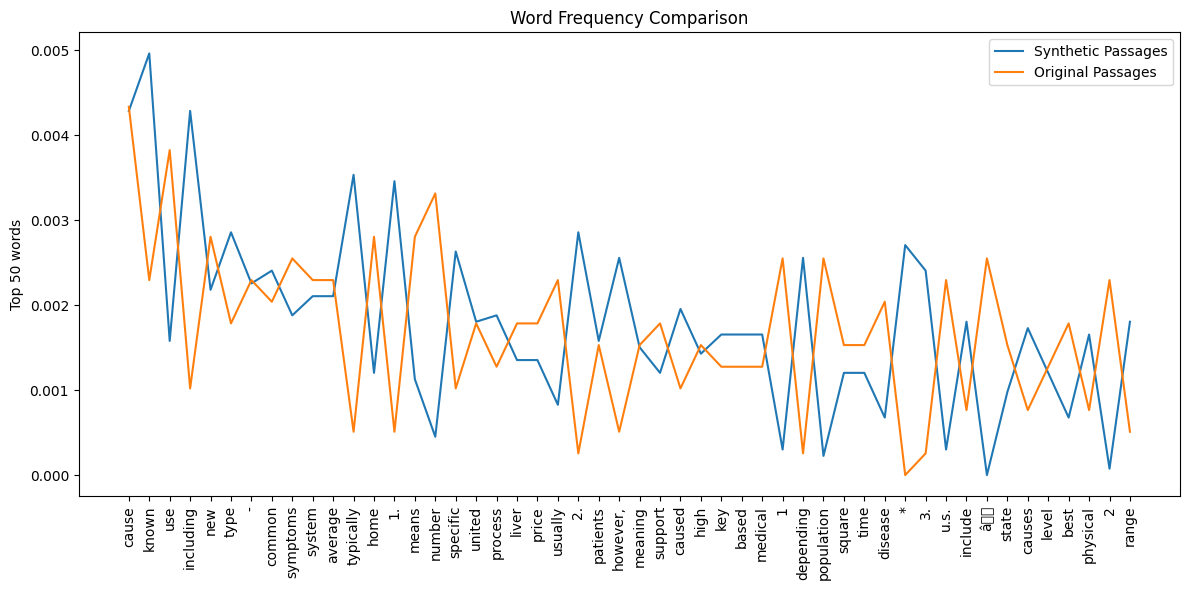

JS divergence: 0.6304109351512015


In [103]:
order = np.argsort(synp_vec + orig_vec)[::-1]

K = 50
vocab_sorted = [vocab[i] for i in order[:K]]
syn_sorted = synp_vec[order][:K]
orig_sorted  = orig_vec[order][:K]

plt.figure(figsize=(12,6))
x = np.arange(len(vocab_sorted))

plt.plot(x, syn_sorted, label="Synthetic Passages")
plt.plot(x, orig_sorted, label="Original Passages")

plt.xticks(x, vocab_sorted, rotation=90)
plt.ylabel("Normalized Frequency")
plt.ylabel(f"Top {K} words")
plt.title("Word Frequency Comparison")
plt.legend()
plt.tight_layout()
plt.show()
print("JS divergence:", js)

# Other exploration

In [3]:
# Loading in datasets
data_dir = "/work/mbouthil/datasets/msmarco"
corpus, queries, q_rels = GenericDataLoader(data_folder=data_dir).load(split='train')

100%|██████████| 8841823/8841823 [01:17<00:00, 114444.02it/s]


In [4]:
last_key = -1
for key in corpus.keys():
    if int(last_key) + 1 != int(key):
        break
    last_key = int(key)

In [18]:
print(len(synp_corpus))
print(len(synq_corpus))
print(len(synp_corpus)-len(synq_corpus))

9319410
8841823
477587


In [22]:
max_key = len(synq_corpus)

print(synp_corpus[str(max_key+4)])

{'text': 'The word convict, in its original context, implies bringing to light or exposing error, often accompanied by reproving or rebuking. It signifies the acquisition of knowledge about believing or doing something wrong, but it does not necessarily imply a positive response from the individual. Similarly, the English word convict is used in a comparable manner.', 'title': ''}


In [18]:
keys = [int(key) for key in synq_corpus.keys()]
print(max(keys))
print(min(keys))
print(len(keys))

8841822
0
8841823


In [20]:
with open('/work/mbouthil/datasets/msmarco/corpus.jsonl') as f:
    for i in range(5):
        doc = json.loads(next(f))
        print(doc["_id"])

0
1
2
3
4
